# Data preparation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel("/kaggle/input/romanian-school-network-2022-2023/2022_2023_retea_scolara.xlsx")

In [3]:
df.head()

,An,Judet PJ,Localitate PJ,Cod SIRUTA PJ,Mediu loc. PJ,Cod SIIIR PJ,Denumire PJ,Localitate unitate,Cod SIRUTA unitate,Mediu loc. unitate,...,Stare Primar,Data Primar,Stare Gimnazial,Data Gimnazial,Stare Liceal,Data Liceal,Stare Postliceal,Data Postliceal,Stare Profesional,Data Profesional
0,2022-2023,AB,ABRUD,1160,URBAN,161102892,"LICEUL ""HOREA, CLOSCA SI CRISAN"" ABRUD",ABRUD,1160,URBAN,...,Acreditat,01/09/2013,Acreditat,01/09/2013,Acreditat,01/09/2013,Acreditat,01/09/2013,Acreditat,01/09/2013
1,2022-2023,AB,ABRUD,1160,URBAN,161100031,"SCOALA GIMNAZIALA ""AVRAM IANCU"" ABRUD",ABRUD,1160,URBAN,...,Acreditat,01/09/2013,Acreditat,01/09/2013,NaN,NaN,NaN,NaN,NaN,NaN
2,2022-2023,AB,ABRUD,1160,URBAN,161100031,"SCOALA GIMNAZIALA ""AVRAM IANCU"" ABRUD",ABRUD,1160,URBAN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2022-2023,AB,AIUD,1222,URBAN,161103328,"COLEGIUL NATIONAL ""BETHLEN GABOR"" AIUD",AIUD,1222,URBAN,...,Acreditat,01/09/2013,Acreditat,01/09/2013,Acreditat,01/09/2013,Acreditat,01/09/2013,Acreditat,01/09/2013
4,2022-2023,AB,AIUD,1222,URBAN,161103328,"COLEGIUL NATIONAL ""BETHLEN GABOR"" AIUD",AIUD,1222,URBAN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.columns

Index(['An', 'Judet PJ', 'Localitate PJ', 'Cod SIRUTA PJ', 'Mediu loc. PJ',
       'Cod SIIIR PJ', 'Denumire PJ', 'Localitate unitate',
       'Cod SIRUTA unitate', 'Mediu loc. unitate', 'Cod SIRUES',
       'Cod SIIIR unitate', 'Denumire scurta unitate',
       'Denumire lunga unitate', 'Tip unitate', 'Statut unitate', 'Cod fiscal',
       'Mod functionare', 'Forma finantare', 'Forma proprietate', 'Strada',
       'Numar', 'Cod postal', 'Telefon', 'Fax', 'Email', 'Atribut Website',
       'Data website', 'Atribut Email', 'Data email',
       'Numar niveluri asociate', 'Stare Antepreșcolar', 'Data Antepreșcolar',
       'Stare Preșcolar', 'Data Preșcolar', 'Stare Primar', 'Data Primar',
       'Stare Gimnazial', 'Data Gimnazial', 'Stare Liceal', 'Data Liceal',
       'Stare Postliceal', 'Data Postliceal', 'Stare Profesional',
       'Data Profesional'],
      dtype='object')

Let's create, for your conveniency, a dictionary with translation of the column names from original Romanian to English.

In [5]:
column_map = {
  "An": "Year",
  "Judet PJ": "County (legal entity)",
  "Localitate PJ": "Locality (legal entity)",
  "Cod SIRUTA PJ": "SIRUTA code (legal entity)",
  "Mediu loc. PJ": "Locality environment (legal entity)",
  "Cod SIIIR PJ": "SIIIR code (legal entity)",
  "Denumire PJ": "Name (legal entity)",
  "Localitate unitate": "Unit locality",
  "Cod SIRUTA unitate": "SIRUTA code (unit)",
  "Mediu loc. unitate": "Locality environment (unit)",
  "Cod SIRUES": "SIRUES code",
  "Cod SIIIR unitate": "SIIIR code (unit)",
  "Denumire scurta unitate": "Unit short name",
  "Denumire lunga unitate": "Unit full name",
  "Tip unitate": "Unit type",
  "Statut unitate": "Unit status",
  "Cod fiscal": "Fiscal code",
  "Mod functionare": "Operating mode",
  "Forma finantare": "Funding type",
  "Forma proprietate": "Ownership type",
  "Strada": "Street",
  "Numar": "Street number",
  "Cod postal": "Postal code",
  "Telefon": "Phone",
  "Fax": "Fax",
  "Email": "Email",
  "Atribut Website": "Website attribute",
  "Data website": "Website date",
  "Atribut Email": "Email attribute",
  "Data email": "Email date",
  "Numar niveluri asociate": "Number of associated levels",
  "Stare Antepreșcolar": "Pre-preschool status",
  "Data Antepreșcolar": "Pre-preschool date",
  "Stare Preșcolar": "Preschool status",
  "Data Preșcolar": "Preschool date",
  "Stare Primar": "Primary level status",
  "Data Primar": "Primary level date",
  "Stare Gimnazial": "Gymnasium (lower secondary) status",
  "Data Gimnazial": "Gymnasium (lower secondary) date",
  "Stare Liceal": "High school status",
  "Data Liceal": "High school date",
  "Stare Postliceal": "Post-secondary status",
  "Data Postliceal": "Post-secondary date",
  "Stare Profesional": "Vocational status",
  "Data Profesional": "Vocational date"
}

Let's apply the changes to the column names.

In [6]:
df = df.rename(columns = column_map)

Let's check it applied correctly.

In [7]:
df.head()

,Year,County (legal entity),Locality (legal entity),SIRUTA code (legal entity),Locality environment (legal entity),SIIIR code (legal entity),Name (legal entity),Unit locality,SIRUTA code (unit),Locality environment (unit),...,Primary level status,Primary level date,Gymnasium (lower secondary) status,Gymnasium (lower secondary) date,High school status,High school date,Post-secondary status,Post-secondary date,Vocational status,Vocational date
0,2022-2023,AB,ABRUD,1160,URBAN,161102892,"LICEUL ""HOREA, CLOSCA SI CRISAN"" ABRUD",ABRUD,1160,URBAN,...,Acreditat,01/09/2013,Acreditat,01/09/2013,Acreditat,01/09/2013,Acreditat,01/09/2013,Acreditat,01/09/2013
1,2022-2023,AB,ABRUD,1160,URBAN,161100031,"SCOALA GIMNAZIALA ""AVRAM IANCU"" ABRUD",ABRUD,1160,URBAN,...,Acreditat,01/09/2013,Acreditat,01/09/2013,NaN,NaN,NaN,NaN,NaN,NaN
2,2022-2023,AB,ABRUD,1160,URBAN,161100031,"SCOALA GIMNAZIALA ""AVRAM IANCU"" ABRUD",ABRUD,1160,URBAN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2022-2023,AB,AIUD,1222,URBAN,161103328,"COLEGIUL NATIONAL ""BETHLEN GABOR"" AIUD",AIUD,1222,URBAN,...,Acreditat,01/09/2013,Acreditat,01/09/2013,Acreditat,01/09/2013,Acreditat,01/09/2013,Acreditat,01/09/2013
4,2022-2023,AB,AIUD,1222,URBAN,161103328,"COLEGIUL NATIONAL ""BETHLEN GABOR"" AIUD",AIUD,1222,URBAN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
df.columns

Index(['Year', 'County (legal entity)', 'Locality (legal entity)',
       'SIRUTA code (legal entity)', 'Locality environment (legal entity)',
       'SIIIR code (legal entity)', 'Name (legal entity)', 'Unit locality',
       'SIRUTA code (unit)', 'Locality environment (unit)', 'SIRUES code',
       'SIIIR code (unit)', 'Unit short name', 'Unit full name', 'Unit type',
       'Unit status', 'Fiscal code', 'Operating mode', 'Funding type',
       'Ownership type', 'Street', 'Street number', 'Postal code', 'Phone',
       'Fax', 'Email', 'Website attribute', 'Website date', 'Email attribute',
       'Email date', 'Number of associated levels', 'Pre-preschool status',
       'Pre-preschool date', 'Preschool status', 'Preschool date',
       'Primary level status', 'Primary level date',
       'Gymnasium (lower secondary) status',
       'Gymnasium (lower secondary) date', 'High school status',
       'High school date', 'Post-secondary status', 'Post-secondary date',
       'Vocational st

# Data exploration

## Count of units per county

Let's see how many educational units we have per county.

In [9]:
units_per_county = df.groupby("County (legal entity)")["Unit type"].count().reset_index()

print(units_per_county)

   County (legal entity)  Unit type
0                     AB        470
1                     AG        515
2                     AR        462
3                      B        739
4                     BC        502
5                     BH        750
6                     BN        311
7                     BR        252
8                     BT        479
9                     BV        427
10                    BZ        483
11                    CJ        475
12                    CL        330
13                    CS        412
14                    CT        532
15                    CV        317
16                    DB        510
17                    DJ        572
18                    GJ        453
19                    GL        441
20                    GR        193
21                    HD        260
22                    HR        438
23                    IF        288
24                    IL        155
25                    IS        674
26                    MH    

## Map the counties codes to full names


Let's map the counties codes to full names.

In [10]:
ro_counties = {
    "AB": "Alba",
    "AG": "Argeș",
    "AR": "Arad",
    "B":  "București",
    "BC": "Bacău",
    "BH": "Bihor",
    "BN": "Bistrița-Năsăud",
    "BR": "Brăila",
    "BT": "Botoșani",
    "BV": "Brașov",
    "BZ": "Buzău",
    "CJ": "Cluj",
    "CL": "Călărași",
    "CS": "Caraș-Severin",
    "CT": "Constanța",
    "CV": "Covasna",
    "DB": "Dâmbovița",
    "DJ": "Dolj",
    "GJ": "Gorj",
    "GL": "Galați",
    "GR": "Giurgiu",
    "HD": "Hunedoara",
    "HR": "Harghita",
    "IF": "Ilfov",
    "IL": "Ialomița",
    "IS": "Iași",
    "MH": "Mehedinți",
    "MM": "Maramureș",
    "MS": "Mureș",
    "NT": "Neamț",
    "OT": "Olt",
    "PH": "Prahova",
    "SB": "Sibiu",
    "SJ": "Sălaj",
    "SM": "Satu Mare",
    "SV": "Suceava",
    "TL": "Tulcea",
    "TM": "Timiș",
    "TR": "Teleorman",
    "VL": "Vâlcea",
    "VN": "Vrancea",
    "VS": "Vaslui"
}


In [11]:
df["county_name"] = df["County (legal entity)"].map(ro_counties)

Let's check the distribution.

In [12]:
units_per_county = df.groupby("county_name")["Unit type"].count().reset_index()

print(units_per_county)

        county_name  Unit type
0              Alba        470
1              Arad        462
2             Argeș        515
3             Bacău        502
4             Bihor        750
5   Bistrița-Năsăud        311
6          Botoșani        479
7            Brașov        427
8            Brăila        252
9         București        739
10            Buzău        483
11    Caraș-Severin        412
12             Cluj        475
13        Constanța        532
14          Covasna        317
15         Călărași        330
16             Dolj        572
17        Dâmbovița        510
18           Galați        441
19          Giurgiu        193
20             Gorj        453
21         Harghita        438
22        Hunedoara        260
23         Ialomița        155
24             Iași        674
25            Ilfov        288
26        Maramureș        407
27        Mehedinți        205
28            Mureș        617
29            Neamț        328
30              Olt        415
31      

## Count of municipalities per county

In [13]:
locality_per_county = df.groupby("county_name")["Locality (legal entity)"].nunique().reset_index()

print(locality_per_county)

        county_name  Locality (legal entity)
0              Alba                       81
1              Arad                       87
2             Argeș                      102
3             Bacău                       99
4             Bihor                      109
5   Bistrița-Năsăud                       67
6          Botoșani                       81
7            Brașov                       61
8            Brăila                       45
9         București                        6
10            Buzău                       90
11    Caraș-Severin                       76
12             Cluj                       85
13        Constanța                       71
14          Covasna                       46
15         Călărași                       57
16             Dolj                      112
17        Dâmbovița                       92
18           Galați                       71
19          Giurgiu                       58
20             Gorj                       71
21        

## Number of different types of units per county


In [14]:
unique_types_per_county = df.groupby("county_name")["Unit type"].nunique().reset_index()

unique_types_per_county.columns = ["County", "Number of different unit types"]
print(unique_types_per_county)

             County  Number of different unit types
0              Alba                               8
1              Arad                               9
2             Argeș                               9
3             Bacău                               9
4             Bihor                               8
5   Bistrița-Năsăud                               8
6          Botoșani                               8
7            Brașov                               8
8            Brăila                               8
9         București                              10
10            Buzău                               8
11    Caraș-Severin                               8
12             Cluj                               9
13        Constanța                               9
14          Covasna                               8
15         Călărași                               8
16             Dolj                               9
17        Dâmbovița                               8
18          

## Breakdown by county and unit type


Note: "Unitate de invatamant" means "Educational unit" and is the school. The rest are auxiliary educational units, including units for continous learning for teachers, vocational clubs etc.

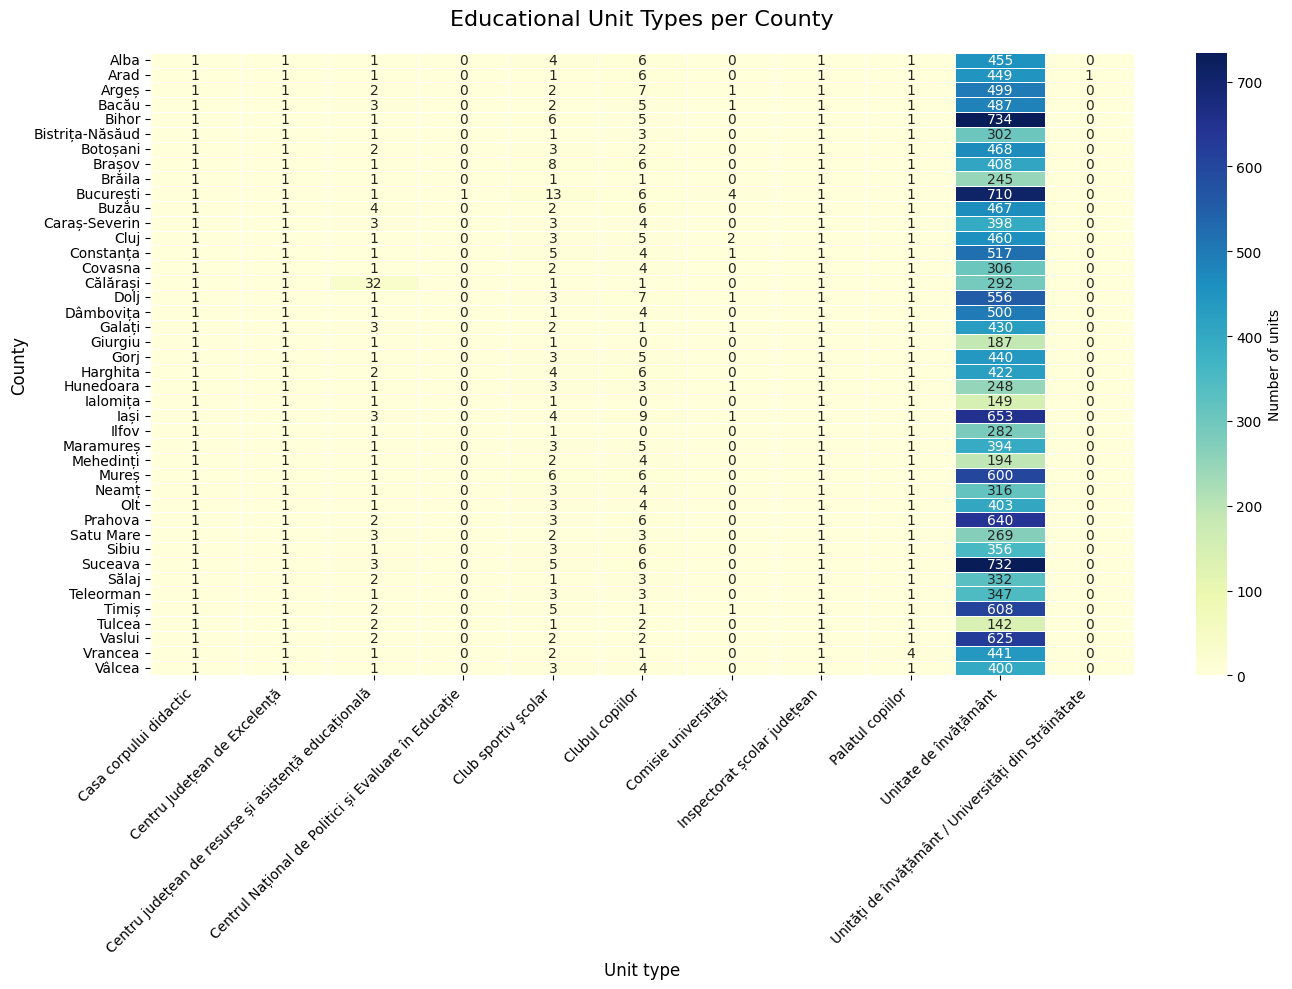

In [15]:
crosstab_units = pd.crosstab(df["county_name"], df["Unit type"])

plt.figure(figsize=(14, 10))

# Heatmap
ax = sns.heatmap(
    crosstab_units,
    cmap="YlGnBu",        # nice blue/green palette
    linewidths=0.5,       # thin grid lines
    annot=True,           # show the counts inside cells
    fmt="d",              # integer format
    cbar_kws={'label': 'Number of units'}  # colorbar label
)

# Titles and labels
plt.title("Educational Unit Types per County", fontsize=16, pad=20)
plt.xlabel("Unit type", fontsize=12)
plt.ylabel("County", fontsize=12)

# Rotate x-labels for readability
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## Number of units per county

We are showing Bucharest county (it is the capital city) with red.

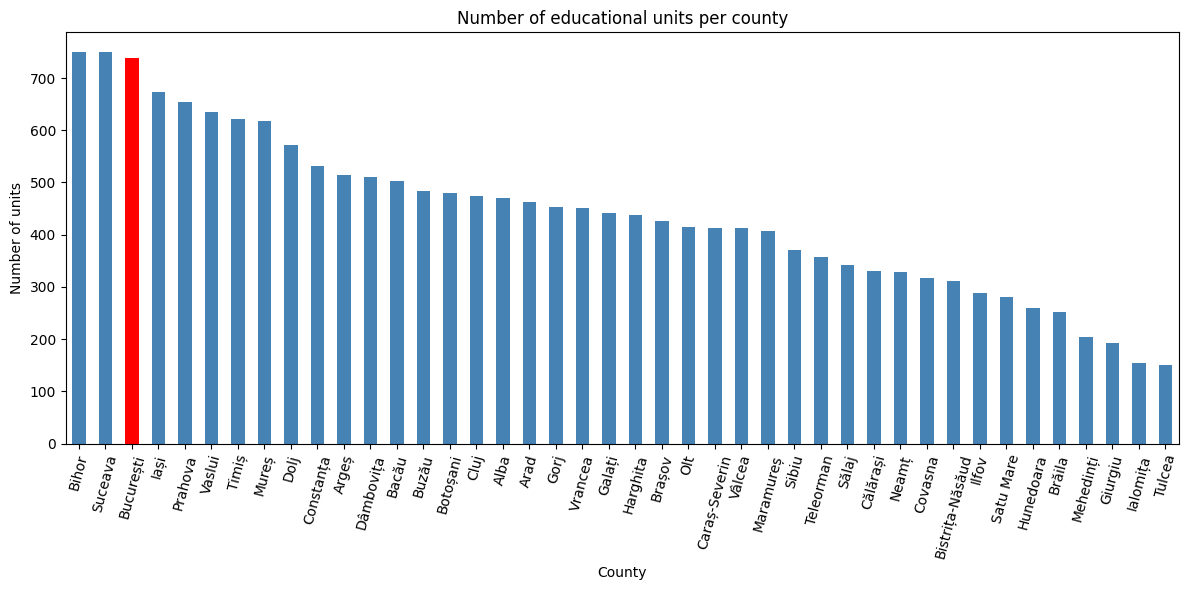

In [16]:

counts = df["county_name"].value_counts()
colors = ["red" if idx in ["B", "București", "Bucharest"] else "steelblue" for idx in counts.index]

plt.figure(figsize=(12,6))
counts.plot(kind="bar", color=colors)
plt.title("Number of educational units per county")
plt.xlabel("County")
plt.ylabel("Number of units")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

## Number of localities per county

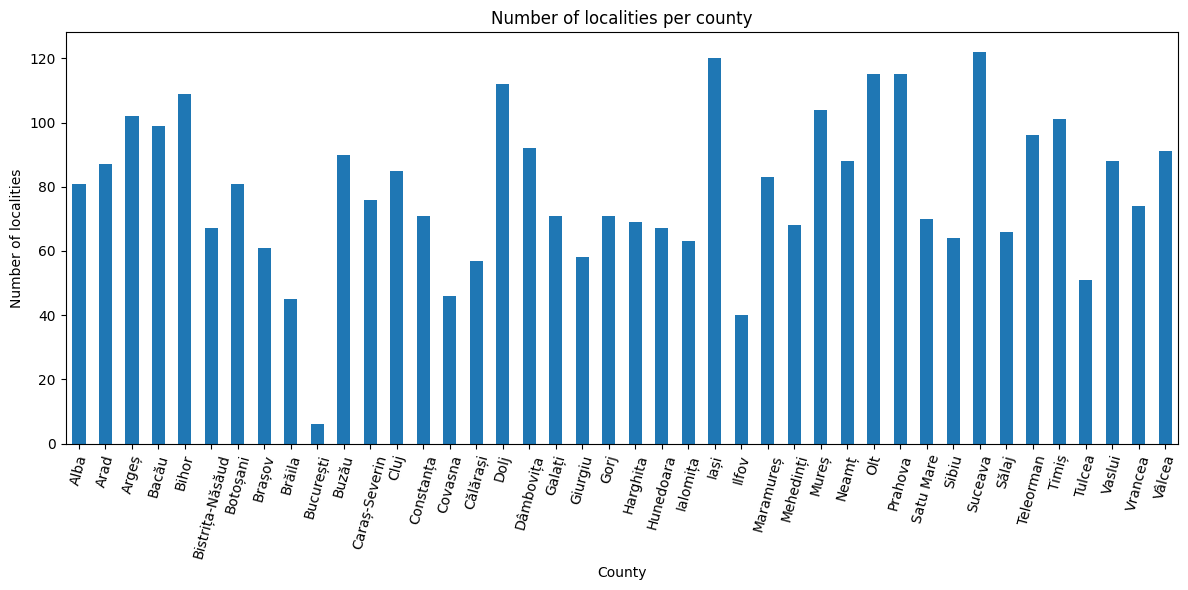

In [17]:

locality_per_county = df.groupby("county_name")["Locality (legal entity)"].nunique()

plt.figure(figsize=(12,6))
locality_per_county.plot(kind="bar",)
plt.title("Number of localities per county")
plt.xlabel("County")
plt.ylabel("Number of localities")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

The localities in Bucharest are actually the subdivision of the capital city, called Sector (from 1 to 6).

In [18]:
for item in list(df.loc[df["County (legal entity)"]=="B"]["Locality (legal entity)"].unique()):
    print(item)

BUCUREŞTI SECTORUL 1
BUCUREŞTI SECTORUL 2
BUCUREŞTI SECTORUL 3
BUCUREŞTI SECTORUL 4
BUCUREŞTI SECTORUL 5
BUCUREŞTI SECTORUL 6


## Number of units per county, by unit type and medium

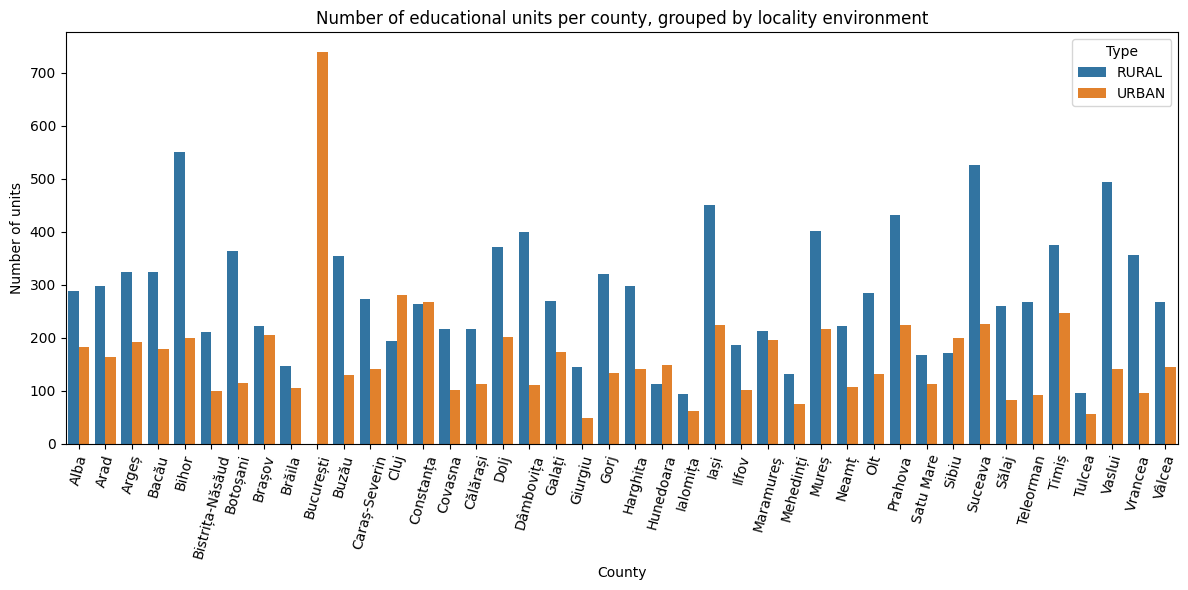

In [19]:
counts = df.groupby(["county_name", "Locality environment (legal entity)"])["Year"].count().reset_index()
counts.columns = ["County", "Type", "Counts"]
plt.figure(figsize=(12,6))
sns.barplot(x=counts["County"], y=counts["Counts"], hue=counts["Type"])
plt.title("Number of educational units per county, grouped by locality environment")
plt.xlabel("County")
plt.ylabel("Number of units")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()